In [ ]:
from re import sub

import matplotlib.pyplot as plt
import numpy as np
from pygeoinf import (
    CGMatrixSolver,
    GaussianMeasure,
    HilbertSpace,
    LinearBayesianInversion,
    LinearForwardProblem,
    LinearOperator,
    RowLinearOperator,
)
from pygeoinf.linear_solvers import ScipyIterativeSolver
from pygeoinf.symmetric_space.sphere import Sobolev
from pyslfp import (
    FingerPrint,
    ice_projection_operator,
    ice_thickness_change_to_load_operator,
    plot,
    sea_level_change_to_load_operator,
    sea_surface_height_operator,
    spatial_mutliplication_operator,
)

from Part_III_Project import (
    ice_thickness_change_measures,
    ocean_dynamic_topography_measures,
)

In [ ]:
# CONFIGURATION VARIABLES

lmax = 64

# Model space parameters
model_sobolev_order = 2
model_length_scale_factor = 0.1  # fraction of mean sea floor radius

# Ice thickness change prior parameters
ice_length_scale_factor = 0.1  # fraction of mean sea floor radius
ice_gmsl_target_std_m = 0.01  # metres
ice_net_thickness_change_m = 0.0  # metres

# Ocean dynamic topography prior parameters
meso_scale_lengthscale = 250e3
meso_scale_std = 0.001
sub_meso_scale_lengthscale = 2e3
sub_meso_scale_std = 0.001

# Altimetry observation parameters
along_track_error = 0.005  # metres
passes = 3  # typically ~ 3 passes every 30 days


altimetry_latitude_max = 66  # degrees
altimetry_latitude_min = -66  # degrees
altimetry_noise_sobolev_order = 1.5
altimetry_noise_length_scale_factor = (
    0.001  # fraction of mean sea floor radius
)
altimetry_noise_std_m = along_track_error / np.sqrt(passes)  # metres

# Solver parameters
solver_rtol = 1e-6
solver_maxiter = 1000

In [ ]:
# FINGERPRINT MODEL INITIALISATION

fp = FingerPrint(
    lmax=lmax,
    earth_model_parameters=FingerPrint.from_standard_non_dimensionalisation(),
)
fp.set_state_from_ice_ng()

In [ ]:
# UNIT CONVERSIONS (physical to non-dimensional)

model_length_scale = (
    model_length_scale_factor * fp.mean_sea_floor_radius
)
ice_length_scale = ice_length_scale_factor * fp.mean_sea_floor_radius
ice_gmsl_target_std = ice_gmsl_target_std_m / fp.length_scale
ice_net_thickness_change = (
    ice_net_thickness_change_m / fp.length_scale
)
meso_scale_lengthscale = meso_scale_lengthscale / fp.length_scale
sub_meso_scale_lengthscale = (
    sub_meso_scale_lengthscale / fp.length_scale
)
meso_scale_std = meso_scale_std / fp.length_scale
sub_meso_scale_std = sub_meso_scale_std / fp.length_scale
altimetry_noise_length_scale = (
    altimetry_noise_length_scale_factor * fp.mean_sea_floor_radius
)
altimetry_noise_std = altimetry_noise_std_m / fp.length_scale

In [ ]:
# HILBERT SPACES

model_space = Sobolev(
    fp.lmax,
    model_sobolev_order,
    model_length_scale,
    radius=fp.mean_sea_floor_radius,
)

fingerprint_op: LinearOperator = fp.as_sobolev_linear_operator(
    model_sobolev_order,
    model_length_scale,
)
load_space: HilbertSpace = fingerprint_op.domain
response_space: HilbertSpace = fingerprint_op.codomain

sea_surface_height_op: LinearOperator = sea_surface_height_operator(
    fp,
    response_space,
)
measurement_space: HilbertSpace = sea_surface_height_op.codomain

In [ ]:
# LINEAR OPERATORS

# Load conversion operators
water_to_load_op: LinearOperator = sea_level_change_to_load_operator(
    fp,
    load_space,
)
ice_to_load_op: LinearOperator = (
    ice_thickness_change_to_load_operator(fp, load_space)
)

# Altimetry spatial mask operator
altimetry_mask_op: LinearOperator = spatial_mutliplication_operator(
    fp.altimetry_projection(
        latitude_max=altimetry_latitude_max,
        latitude_min=altimetry_latitude_min,
        value=0,
    )
    * fp.ocean_function,
    measurement_space,
)

# Error/noise model operator
# Maps [odt_gravitational, odt_direct, instrument_noise] → observed error
altimetry_noise_op = altimetry_mask_op @ RowLinearOperator(
    [
        sea_surface_height_op @ fingerprint_op @ water_to_load_op,
        measurement_space.identity_operator(),
        measurement_space.identity_operator(),
    ],
)

# Signal forward operator: ice thickness change → altimetry observations
ice_to_altimetry_op = (
    altimetry_mask_op
    @ sea_surface_height_op
    @ fingerprint_op
    @ ice_to_load_op
    @ ice_projection_operator(fp, load_space)
)

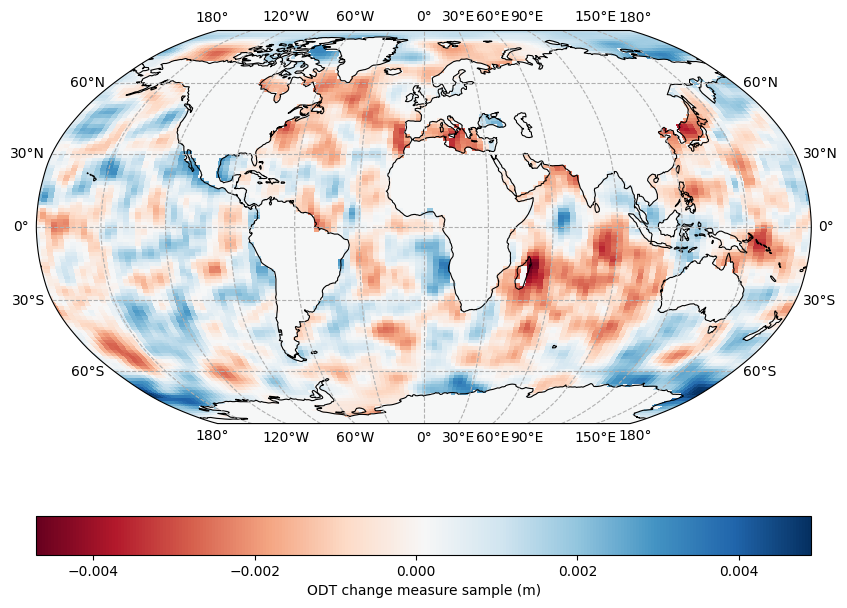

In [ ]:
# GAUSSIAN MEASURES (PRIORS AND ERROR MODELS)

# Ice thickness change prior
ice_thickness_change_measure, _ = ice_thickness_change_measures(
    fingerprint=fp,
    fingerprint_operator=fingerprint_op,
    length_scale=ice_length_scale,
    ice_gmsl_target_std=ice_gmsl_target_std,
    net_thickness_change=ice_net_thickness_change,
)

# Ocean dynamic topography prior
meso, _ = ocean_dynamic_topography_measures(
    fingerprint=fp,
    fingerprint_operator=fingerprint_op,
    length_scale=meso_scale_lengthscale,
    standard_deviation=meso_scale_std,
)
sub_meso, _ = ocean_dynamic_topography_measures(
    fingerprint=fp,
    fingerprint_operator=fingerprint_op,
    length_scale=sub_meso_scale_lengthscale,
    standard_deviation=sub_meso_scale_std,
)
odt_change_measure = meso + sub_meso

# Measurement noise
measurement_noise_measure = measurement_space.point_value_scaled_sobolev_kernel_gaussian_measure(
    altimetry_noise_sobolev_order,
    altimetry_noise_length_scale,
    altimetry_noise_std,
)

# Combined data error measure
error_input_measure = GaussianMeasure.from_direct_sum(
    [
        odt_change_measure,
        odt_change_measure,
        measurement_noise_measure,
    ],
)
data_error_measure = error_input_measure.affine_mapping(
    operator=altimetry_noise_op,
)

# Visualise a sample from the data error measure
fig, ax, im = plot(odt_change_measure.sample() * fp.length_scale)
fig.colorbar(
    im,
    ax=ax,
    label="ODT change measure sample (m)",
    orientation="horizontal",
)

In [ ]:
# FORWARD PROBLEM AND SYNTHETIC DATA

forward_problem = LinearForwardProblem(
    ice_to_altimetry_op,
    data_error_measure=data_error_measure,
)

model_true, data = forward_problem.synthetic_model_and_data(
    ice_thickness_change_measure,
)

In [ ]:
# BAYESIAN INVERSION

inversion = LinearBayesianInversion(
    forward_problem,
    ice_thickness_change_measure,
)

Iteration 5: ||x|| = 1.222760e+10, relative change = 3.050618e-01
Iteration 10: ||x|| = 2.374136e+10, relative change = 1.568451e-01
Iteration 15: ||x|| = 3.156810e+10, relative change = 2.322218e-02
Iteration 20: ||x|| = 3.432508e+10, relative change = 1.648993e-02
Iteration 25: ||x|| = 3.497751e+10, relative change = 1.164570e-02
Iteration 30: ||x|| = 3.555943e+10, relative change = 1.544192e-02
Iteration 35: ||x|| = 3.597940e+10, relative change = 1.521082e-02
Iteration 40: ||x|| = 3.615927e+10, relative change = 7.487312e-03
Iteration 45: ||x|| = 3.592109e+10, relative change = 1.158713e-02
Iteration 50: ||x|| = 3.548519e+10, relative change = 6.497013e-03
Iteration 55: ||x|| = 3.483800e+10, relative change = 1.108446e-02
Iteration 60: ||x|| = 3.371610e+10, relative change = 1.402844e-02
Iteration 65: ||x|| = 3.201865e+10, relative change = 1.835527e-02
Iteration 70: ||x|| = 3.063515e+10, relative change = 1.316563e-02
Iteration 75: ||x|| = 2.948216e+10, relative change = 1.192282e

Text(0.5, 1.0, 'Convergence of Solution Norm')

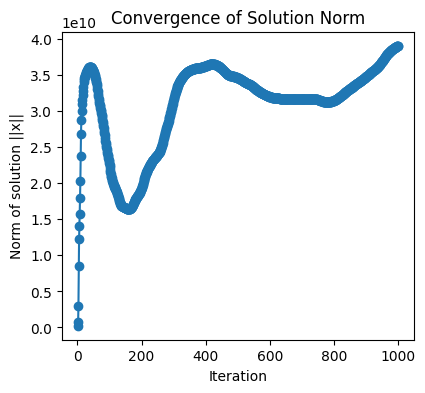

In [ ]:
class ConvergenceMonitor:
    def __init__(self):
        self.iteration = 0
        self.x_norms = []
        self.x_changes = []
        self.prev_x = None

    def __call__(self, xk):
        self.iteration += 1
        x_norm = np.linalg.norm(xk)
        self.x_norms.append(x_norm)

        if self.prev_x is not None:
            change = np.linalg.norm(xk - self.prev_x)
            relative_change = (
                change / x_norm if x_norm > 0 else change
            )
            self.x_changes.append(relative_change)

            if self.iteration % 5 == 0:
                print(
                    f"Iteration {self.iteration}: ||x|| = {x_norm:.6e}, "
                    f"relative change = {relative_change:.6e}",
                )
        elif self.iteration % 5 == 0:
            print(f"Iteration {self.iteration}: ||x|| = {x_norm:.6e}")

        self.prev_x = xk.copy()


monitor = ConvergenceMonitor()
solver = CGMatrixSolver(
    callback=monitor,
    rtol=solver_rtol,
    maxiter=solver_maxiter,
)


model_posterior_measure = inversion.model_posterior_measure(
    data,
    solver,
)

print(f"Total iterations: {monitor.iteration}")
print(f"Number of fingerprint problem solutions: {fp.solver_counter}")


fig = plt.figure(figsize=(10, 4))
ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(range(1, monitor.iteration + 1), monitor.x_norms, marker="o")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Norm of solution ||x||")
ax1.set_title("Convergence of Solution Norm")

In [ ]:
# RESULTS

model_posterior_expectation = model_posterior_measure.expectation

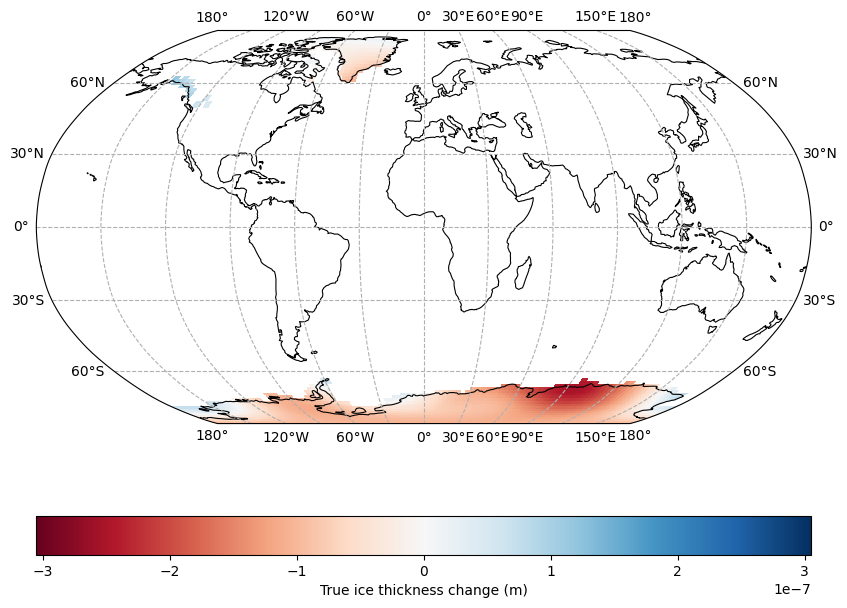

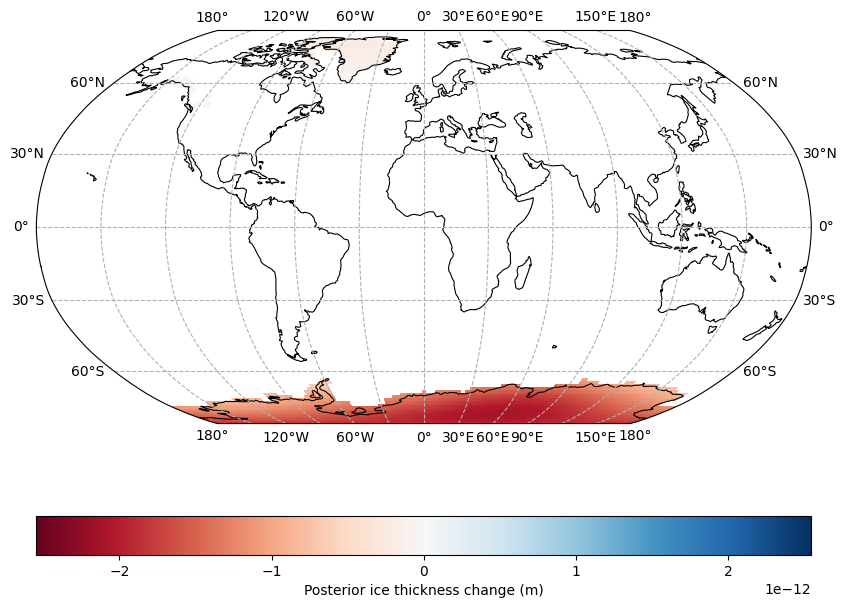

In [ ]:
# VISUALISATION

# Ice thickness change recovery
# ------------------------------------------

# True ice thickness change
fig1, ax1, im1 = plot(
    model_true * fp.length_scale * fp.ice_projection(),
    symmetric=True,
)
fig1.colorbar(
    im1,
    ax=ax1,
    label="True ice thickness change (m)",
    orientation="horizontal",
)

# Posterior expectation (recovered)
fig2, ax2, im2 = plot(
    model_posterior_expectation
    * fp.length_scale
    * fp.ice_projection(),
    symmetric=True,
)
fig2.colorbar(
    im2,
    ax=ax2,
    label="Posterior ice thickness change (m)",
    orientation="horizontal",
)

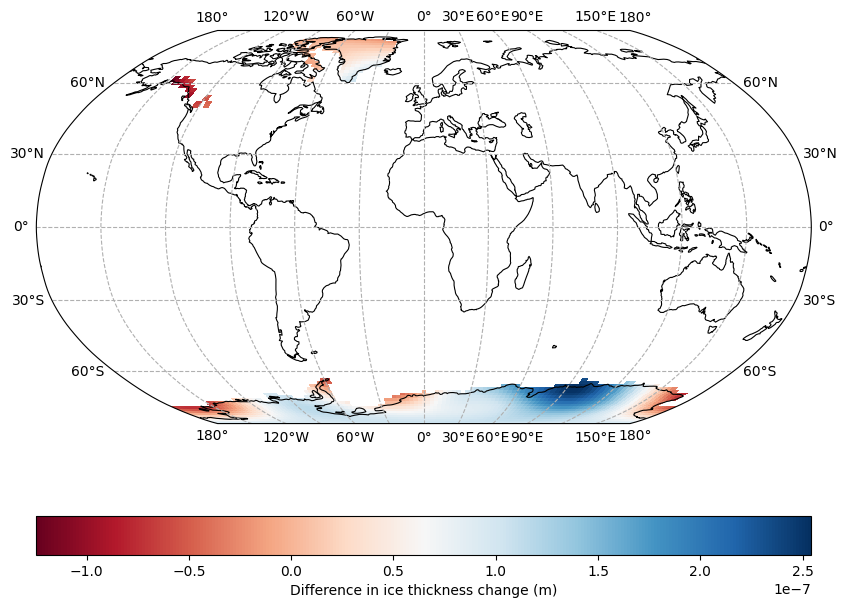

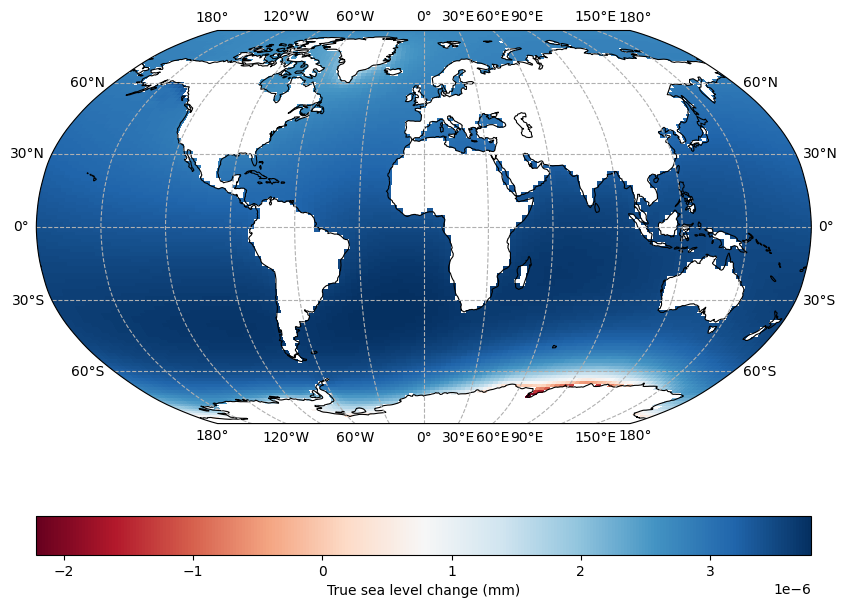

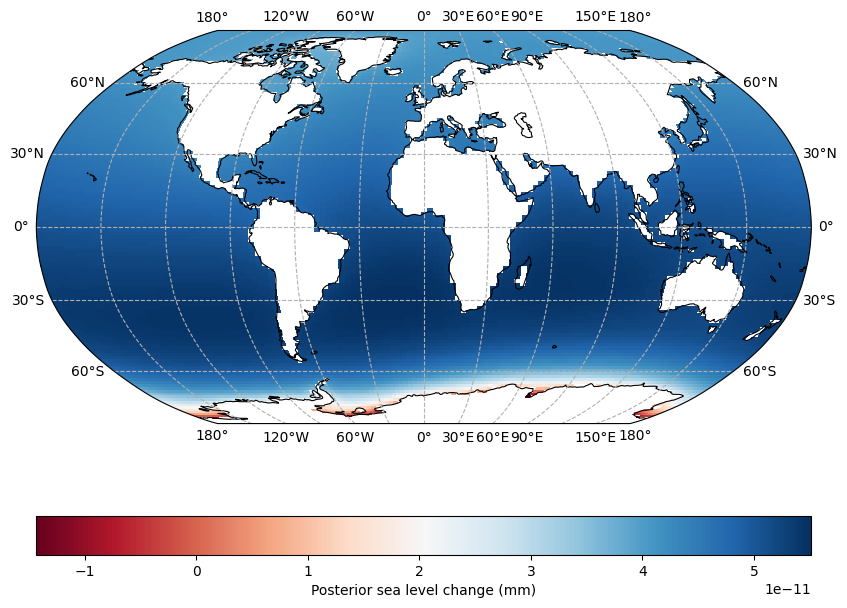

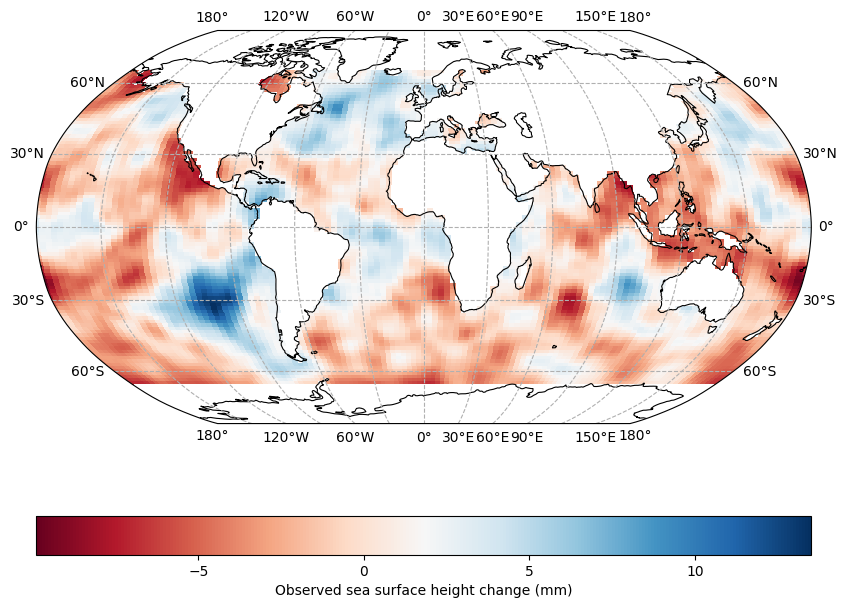

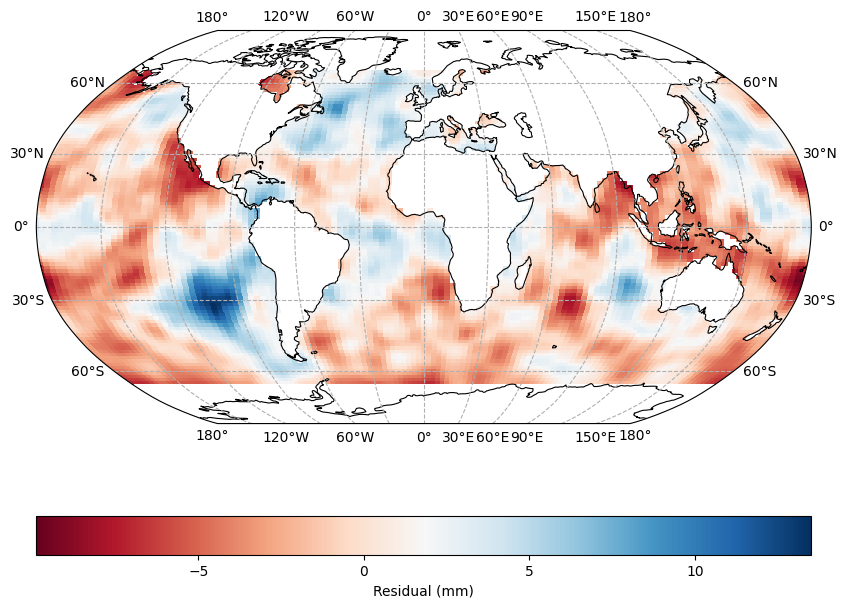

In [ ]:
# Difference (error in recovery)
fig3, ax3, im3 = plot(
    (model_posterior_expectation - model_true)
    * fp.length_scale
    * fp.ice_projection(),
)
fig3.colorbar(
    im3,
    ax=ax3,
    label="Difference in ice thickness change (m)",
    orientation="horizontal",
)


# 2. Sea level change recovery
# --------------------------------------
# Map ice thickness to sea surface height
sea_level_true = (
    sea_surface_height_op
    @ fingerprint_op
    @ ice_to_load_op
    @ ice_projection_operator(fp, load_space)
)(model_true)

sea_level_posterior = (
    sea_surface_height_op
    @ fingerprint_op
    @ ice_to_load_op
    @ ice_projection_operator(fp, load_space)
)(model_posterior_expectation)

# Mask to ocean only
ocean_mask = fp.ocean_projection()

# True sea level fingerprint
fig4, ax4, im4 = plot(
    sea_level_true * ocean_mask * fp.length_scale * 1000,
)
fig4.colorbar(
    im4,
    ax=ax4,
    label="True sea level change (mm)",
    orientation="horizontal",
)

# Predicted sea level fingerprint
fig5, ax5, im5 = plot(
    sea_level_posterior * ocean_mask * fp.length_scale * 1000,
)
fig5.colorbar(
    im5,
    ax=ax5,
    label="Posterior sea level change (mm)",
    orientation="horizontal",
)


# 3. OBSERVED DATA (what the altimeter actually "sees")
# -----------------------------------------------------
# The data includes the altimetry mask and noise
fig6, ax6, im6 = plot(
    data
    * fp.length_scale
    * 1000
    * fp.ocean_projection()
    * fp.altimetry_projection(latitude_min=-66, latitude_max=66),
)


fig6.colorbar(
    im6,
    ax=ax6,
    label="Observed sea surface height change (mm)",
    orientation="horizontal",
)


# 4. DATA RESIDUAL
# -----------------
# How well does the posterior prediction fit the data?
predicted_data = ice_to_altimetry_op(model_posterior_expectation)
data_residual = data - predicted_data

fig7, ax7, im7 = plot(
    data_residual
    * fp.length_scale
    * 1000
    * fp.ocean_projection()
    * fp.altimetry_projection(latitude_min=-66, latitude_max=66),
)
fig7.colorbar(
    im7,
    ax=ax7,
    label="Residual (mm)",
    orientation="horizontal",
)